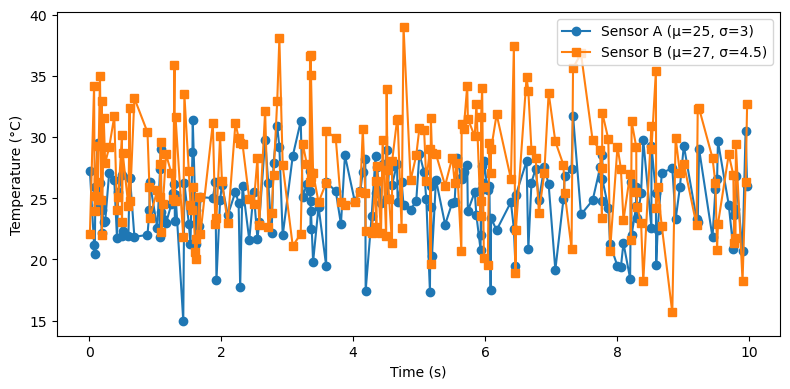

In [1]:
# Generate simulated temperature readings from two sensors.
# Sensor A: mean 25 C, std 3 C, 200 readings.
# Sensor B: mean 27 C, std 4.5 C, 200 readings.
# Also generate 200 timestamps uniformly from 0 to 10 seconds.
# Use np.random.default_rng with a seed = 4309

import numpy as np
import matplotlib.pyplot as plt
 
rng = np.random.default_rng(4309)
n = 200
t = rng.uniform(0, 10, size=n)
 
sensor_a = rng.normal(loc=25.0, scale=3.0, size=n)
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n)
 
# sort by time so plots are sensible
order = np.argsort(t)
t = t[order]
sensor_a = sensor_a[order]
sensor_b = sensor_b[order]
 
plt.figure(figsize=(8,4))
plt.plot(t, sensor_a, 'o-', label='Sensor A (μ=25, σ=3)')
plt.plot(t, sensor_b, 's-', label='Sensor B (μ=27, σ=4.5)')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.tight_layout()
plt.show()

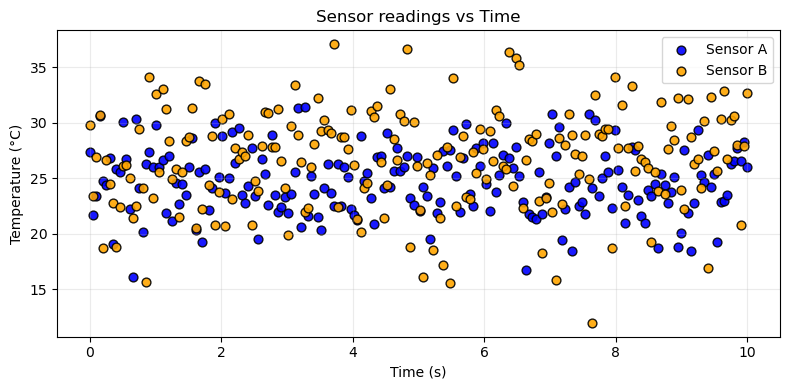

In [3]:
# Scatter plot: sensor reading (y-axis) vs timestamp in seconds (x-axis).
# Color Sensor A points blue and Sensor B points orange.
# Add axis labels with units, a title, and a legend.
import numpy as np
import matplotlib.pyplot as plt
 
# If arrays already exist, skip creation. Otherwise (standalone), create reproducible example:
rng = np.random.default_rng(4309)
n = 200
timestamps = np.linspace(0.0, 10.0, n, dtype=np.float64)          # (200,) float64
sensor_a = rng.normal(loc=25.0, scale=3.0, size=n).astype(np.float64)
sensor_b = rng.normal(loc=27.0, scale=4.5, size=n).astype(np.float64)
 
# Scatter: temperature (y) vs time (x)
plt.figure(figsize=(8,4))
plt.scatter(timestamps, sensor_a, color='blue', edgecolors='k', s=40, alpha=0.9, label='Sensor A')
plt.scatter(timestamps, sensor_b, color='orange', edgecolors='k', s=40, alpha=0.9, label='Sensor B')
plt.xlabel('Time (s)')
plt.ylabel('Temperature (°C)')
plt.title('Sensor readings vs Time')
plt.legend(loc='best')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

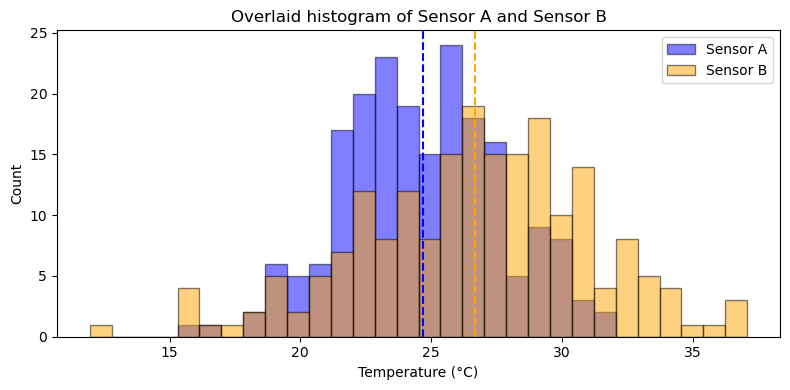

In [4]:
# Overlaid histogram of Sensor A and Sensor B temperature distributions.
# Use 30 bins, alpha=0.5 for transparency so both distributions are visible.
# Add vertical dashed lines at each sensor's mean.
# Include a legend labeling each sensor.

import numpy as np
import matplotlib.pyplot as plt
 
# If running standalone, make example arrays; otherwise use existing names.
try:
     _ = sensor_a  # noqa
     _ = sensor_b
except NameError:
     rng = np.random.default_rng(4309)
     sensor_a = rng.normal(25.0, 3.0, size=200).astype(np.float64)
     sensor_b = rng.normal(27.0, 4.5, size=200).astype(np.float64)
 
 # Ensure correct shapes/dtypes (use local copies to avoid mutating notebook vars)
sa = np.asarray(sensor_a, dtype=np.float64)
sb = np.asarray(sensor_b, dtype=np.float64)
assert sa.shape == (200,) and sb.shape == (200,)
 
# Shared bin edges for 30 bins
bins = np.linspace(min(sa.min(), sb.min()), max(sa.max(), sb.max()), 31)  # 31 edges -> 30 bins
 
plt.figure(figsize=(8,4))
plt.hist(sa, bins=bins, color='blue', alpha=0.5, edgecolor='k', label='Sensor A')
plt.hist(sb, bins=bins, color='orange', alpha=0.5, edgecolor='k', label='Sensor B')
 
 # Vertical dashed lines at means
plt.axvline(sa.mean(), color='blue', linestyle='--', linewidth=1.5)
plt.axvline(sb.mean(), color='orange', linestyle='--', linewidth=1.5)
 
plt.xlabel('Temperature (°C)')
plt.ylabel('Count')
plt.title('Overlaid histogram of Sensor A and Sensor B')
plt.legend(loc='best')
plt.tight_layout()
plt.show()


C:\Users\conno\AppData\Local\Temp\ipykernel_30424\1610396708.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot([sa, sb], labels=['Sensor A', 'Sensor B'], patch_artist=True)


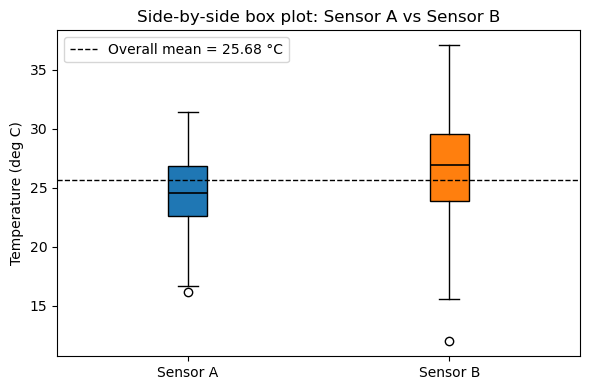

In [5]:
# Side-by-side box plot comparing Sensor A and Sensor B distributions.
# Label x-axis with sensor names, y-axis with "Temperature (deg C)".
# Add a horizontal dashed line at the overall mean of both sensors combined.
import numpy as np
import matplotlib.pyplot as plt
 
# Use existing arrays if present; otherwise create reproducible examples
try:
     _ = sensor_a  # noqa
     _ = sensor_b
except NameError:
     rng = np.random.default_rng(4309)
     sensor_a = rng.normal(25.0, 3.0, size=200).astype(np.float64)
     sensor_b = rng.normal(27.0, 4.5, size=200).astype(np.float64)
 
# Ensure correct shapes/dtypes
sa = np.asarray(sensor_a, dtype=np.float64)
sb = np.asarray(sensor_b, dtype=np.float64)
assert sa.shape == (200,) and sb.shape == (200,)
 
 # Overall mean across both sensors
overall_mean = np.mean(np.concatenate([sa, sb]))
 
 # Side-by-side box plot
plt.figure(figsize=(6,4))
bp = plt.boxplot([sa, sb], labels=['Sensor A', 'Sensor B'], patch_artist=True)
 
 # Color the boxes for clarity
colors = ['C0', 'C1']
for patch, color in zip(bp['boxes'], colors):
     patch.set_facecolor(color)
 # Optionally style medians/whiskers
for median in bp['medians']:
     median.set(color='black', linewidth=1.2)
 
plt.ylabel('Temperature (deg C)')
plt.title('Side-by-side box plot: Sensor A vs Sensor B')
 
 # Horizontal dashed line at overall mean
plt.axhline(overall_mean, color='k', linestyle='--', linewidth=1.0, label=f'Overall mean = {overall_mean:.2f} °C')
plt.legend(loc='best')
plt.tight_layout()
plt.show()